<div class="alert alert-block alert-success">

Consider the following input sentence, which has already been embedded into 3-
dimensional vectors. 

We choose a small embedding dimension for
illustration purposes to ensure it fits on the page without line breaks:

</div>

In [22]:
import torch
inputs = torch.tensor([
    [0.43, 0.15, 0.89], # Your     (x^1)
    [0.55, 0.87, 0.66], # journey  (x^2)
    [0.57, 0.85, 0.64], # starts   (x^3)
    [0.22, 0.58, 0.33], # with     (x^4)
    [0.77, 0.25, 0.10], # one      (x^5)
     [0.05, 0.80, 0.55] # step     (x^6)
])

In [23]:
inputs.shape  # (6, 3) => (sequence_length, embedding_dimension)

torch.Size([6, 3])

tensor([0.4300, 0.5500, 0.5700, 0.2200, 0.7700, 0.0500]) tensor([0.1500, 0.8700, 0.8500, 0.5800, 0.2500, 0.8000]) tensor([0.8900, 0.6600, 0.6400, 0.3300, 0.1000, 0.5500])


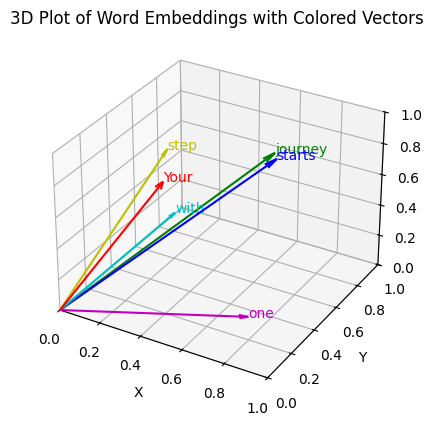

In [24]:
# Create 3D plot with vectors from origin to each point, using different colors
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define word labels and colors for the vectors
words = ['Your', 'journey', 'starts', 'with', 'one', 'step']
colors = ['r', 'g', 'b', 'c', 'm', 'y']

# Extract coordinates from the inputs tensor
x_coords = inputs[:, 0]  # First dimension
y_coords = inputs[:, 1]  # Second dimension  
z_coords = inputs[:, 2]  # Third dimension

print(x_coords, y_coords, z_coords)
# Plot each vector with a different color and annotate with corresponding word
for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    # Draw vector from origin to the point (x,y,z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()

<div class="alert alert-block alert-info">
    
Each row represents a word, and each column represents an embedding dimension
    
</div>

<div class="alert alert-block alert-info">
    
The second input token serves as the query    
</div>

In [25]:
query = inputs[1]  # 2nd input token is the query: "journey"

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query) # dot product (transpose not necessary here since they are 1-dim vectors)

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


<div class="alert alert-block alert-success">

The main goal behind the normalization  is to obtain attention weights
that sum up to 1. 

This normalization is a convention that is useful for interpretation and for
maintaining training stability in an LLM. 

Here's a straightforward method for achieving this
normalization step:

</div>

In [26]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()
print("Attention weights:", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


<div class="alert alert-block alert-info">
    
In practice, it's more common and advisable to use the softmax function for normalization.

This approach is better at managing extreme values and offers more favorable gradient
properties during training. 

Below is a basic implementation of the softmax function for
normalizing the attention scores: 
</div>

In [27]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)

print("Attention weights:", attn_weights_2_naive)
print("Sum:", attn_weights_2_naive.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


<div class="alert alert-block alert-info">
    
As the output shows, the softmax function also meets the objective and normalizes the
attention weights such that they sum to 1:
</div>

<div class="alert alert-block alert-warning">

Note that this naive softmax implementation (softmax_naive) may encounter numerical
instability problems, such as overflow and underflow, when dealing with large or small input
values. 

Therefore, in practice, it's advisable to use the PyTorch implementation of softmax,
which has been extensively optimized for performance:
    
</div>

## Understanding Softmax Numerical Instability

Let's explore why the naive softmax can be problematic with concrete examples:

In [33]:
# Example 1: OVERFLOW problem with large values
print("=== OVERFLOW PROBLEM ===")
large_values = torch.tensor([30.0, 35.0, 40.0])
print(f"Input values: {large_values}")

# Try naive softmax
print("\nNaive softmax:")
try:
    exp_values = torch.exp(large_values)
    print(f"exp() values: {exp_values}")
    naive_result = exp_values / exp_values.sum()
    print(f"Naive softmax result: {naive_result}")
    print(f"Sum: {naive_result.sum()}")
except Exception as e:
    print(f"Error: {e}")

# Compare with PyTorch softmax
print("\nPyTorch softmax:")
torch_result = torch.softmax(large_values, dim=0)
print(f"PyTorch softmax result: {torch_result}")
print(f"Sum: {torch_result.sum()}")
print(f"Are results finite? {torch.isfinite(torch_result).all()}")

=== OVERFLOW PROBLEM ===
Input values: tensor([30., 35., 40.])

Naive softmax:
exp() values: tensor([1.0686e+13, 1.5860e+15, 2.3539e+17])
Naive softmax result: tensor([4.5094e-05, 6.6925e-03, 9.9326e-01])
Sum: 1.0

PyTorch softmax:
PyTorch softmax result: tensor([4.5094e-05, 6.6925e-03, 9.9326e-01])
Sum: 1.0
Are results finite? True
Are results finite? True


In [34]:
# Example 2: UNDERFLOW problem with very negative values
print("\n=== UNDERFLOW PROBLEM ===")
small_values = torch.tensor([-50.0, -55.0, -60.0])
print(f"Input values: {small_values}")

# Try naive softmax
print("\nNaive softmax:")
exp_values_small = torch.exp(small_values)
print(f"exp() values: {exp_values_small}")
print(f"Are exp values zero? {(exp_values_small == 0).all()}")

if exp_values_small.sum() == 0:
    print("Division by zero! This will cause NaN")
    naive_result_small = exp_values_small / exp_values_small.sum()
    print(f"Naive result: {naive_result_small}")
else:
    naive_result_small = exp_values_small / exp_values_small.sum()
    print(f"Naive result: {naive_result_small}")

# Compare with PyTorch softmax
print("\nPyTorch softmax:")
torch_result_small = torch.softmax(small_values, dim=0)
print(f"PyTorch result: {torch_result_small}")
print(f"Sum: {torch_result_small.sum()}")
print(f"Are results finite? {torch.isfinite(torch_result_small).all()}")


=== UNDERFLOW PROBLEM ===
Input values: tensor([-50., -55., -60.])

Naive softmax:
exp() values: tensor([1.9287e-22, 1.2996e-24, 8.7565e-27])
Are exp values zero? False
Naive result: tensor([9.9326e-01, 6.6925e-03, 4.5094e-05])

PyTorch softmax:
PyTorch result: tensor([9.9326e-01, 6.6925e-03, 4.5094e-05])
Sum: 1.0
Are results finite? True


In [ ]:
# Example 3: How PyTorch solves this - the "subtract max" trick
print("\n=== HOW PYTORCH SOLVES THIS ===")
print("PyTorch uses the mathematically equivalent but numerically stable formula:")
print("softmax(x) = exp(x - max(x)) / sum(exp(x - max(x)))")
print()

def stable_softmax(x):
    """Numerically stable softmax implementation"""
    # Subtract the maximum value to prevent overflow
    x_shifted = x - torch.max(x)
    exp_values = torch.exp(x_shifted)
    return exp_values / exp_values.sum()

# Test with our problematic large values
print("Testing with large values:")
large_values = torch.tensor([30.0, 35.0, 40.0])
print(f"Original values: {large_values}")
print(f"After subtracting max: {large_values - torch.max(large_values)}")

stable_result = stable_softmax(large_values)
torch_result = torch.softmax(large_values, dim=0)

print(f"Our stable implementation: {stable_result}")
print(f"PyTorch implementation:    {torch_result}")
print(f"Results are equal? {torch.allclose(stable_result, torch_result)}")
print()

# Test with small values
print("Testing with very negative values:")
small_values = torch.tensor([-50.0, -55.0, -60.0])
print(f"Original values: {small_values}")
print(f"After subtracting max: {small_values - torch.max(small_values)}")

stable_result_small = stable_softmax(small_values)
torch_result_small = torch.softmax(small_values, dim=0)

print(f"Our stable implementation: {stable_result_small}")
print(f"PyTorch implementation:    {torch_result_small}")
print(f"Results are equal? {torch.allclose(stable_result_small, torch_result_small)}")

### The Numerical Instability Problems:
1. Overflow Problem
When attention scores are large (like 30, 35, 40), computing exp(40) gives approximately 2.4×10¹⁷
This can exceed floating-point limits and produce infinity values
Results in invalid softmax outputs
2. Underflow Problem
When scores are very negative (like -50, -55, -60), exp(-60) becomes approximately 8.8×10⁻²⁷
This is so small it gets rounded to zero due to floating-point precision
Leads to division by zero when all exponentials become zero
3. PyTorch's Solution
Uses the mathematically equivalent but numerically stable formula:
softmax(x) = exp(x - max(x)) / sum(exp(x - max(x)))
By subtracting the maximum value first, all inputs become ≤ 0
This prevents overflow (the largest exp value becomes 1)
Maintains the relative differences between values
Produces identical results to the naive formula but without numerical issues
The examples show concrete cases where the naive implementation fails but PyTorch's optimized version works perfectly. This is why it's always recommended to use torch.softmax() in practice!
### Summary: Why Numerical Stability Matters

**The Problems:**

1. **Overflow**: When attention scores are large (e.g., 30, 40), `exp(40) ≈ 2.4×10¹⁷` can exceed floating-point limits, causing infinity values.

2. **Underflow**: When scores are very negative (e.g., -50, -60), `exp(-60) ≈ 8.8×10⁻²⁷` becomes zero due to floating-point precision limits, leading to division by zero.

**The Solution:**
PyTorch uses the mathematically equivalent formula: `softmax(x) = exp(x - max(x)) / sum(exp(x - max(x)))`

- Subtracting the maximum value shifts all inputs to be ≤ 0
- This prevents overflow (largest exp value is 1)
- Maintains relative differences between values
- Results are identical to the naive formula but numerically stable

**Key Takeaway:** Always use `torch.softmax()` in practice for reliable, optimized computation!

In [28]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


<div class="alert alert-block alert-info">
    
In this case, we can see that it yields the same results as our previous softmax_naive
function:
</div>

<div class="alert alert-block alert-success">

The context vector z(2)is calculated as a weighted sum of all input
vectors. 

This involves multiplying each input vector by its corresponding attention weight:

</div>

In [32]:
query = inputs[1]  # journey
context_vector = torch.zeros(inputs.shape[1])  # Initialize context vector with zeros
for i, x_i in enumerate(inputs):
    context_vector += attn_weights_2[i] * x_i
    print(context_vector)
print("Context vector:", context_vector)

tensor([0.0596, 0.0208, 0.1233])
tensor([0.1904, 0.2277, 0.2803])
tensor([0.3234, 0.4260, 0.4296])
tensor([0.3507, 0.4979, 0.4705])
tensor([0.4340, 0.5250, 0.4813])
tensor([0.4419, 0.6515, 0.5683])
Context vector: tensor([0.4419, 0.6515, 0.5683])


## Explanation of Context Vector Calculation

Let's break down what happens in the context vector calculation step by step:

### Step-by-Step Example:

**Given:**
- Query = `[0.55, 0.87, 0.66]` (the "journey" embedding)
- Input embeddings (6 words × 3 dimensions)
- Attention weights calculated from the actual dot products and softmax

**What the code does:**

1. **Initialize**: Start with a zero vector `[0.0, 0.0, 0.0]`

2. **For each word**: Multiply its embedding by its attention weight, then add to context vector

3. **The calculation process**:
   - For each word embedding `x_i`, multiply it by its corresponding attention weight `attn_weights_2[i]`
   - Add the result to the running context vector sum
   - Continue until all words are processed

4. **Final result**: Sum all weighted embeddings to get the context vector

**Key insight**: Words with higher attention weights contribute more to the final context vector. This allows the model to "focus" on the most relevant words when processing the query word "journey".

**Note**: The exact attention weight values depend on the similarity (dot product) between each word's embedding and the query embedding, normalized through softmax. Run the code above to see the actual calculated weights!

In [30]:
# Let's show the ACTUAL numerical example with real values from our notebook
print("=== ACTUAL NUMERICAL EXAMPLE ===")
print("Using the real embeddings and attention weights from above:")
print()

# Show the actual attention weights that were calculated
print("Attention weights (attn_weights_2):")
for i, weight in enumerate(attn_weights_2):
    word = ['Your', 'journey', 'starts', 'with', 'one', 'step'][i]
    print(f"  {word}: {weight:.4f}")
print()

# Show the step-by-step context vector calculation with real numbers
print("Context vector calculation step-by-step:")
context_demo = torch.zeros(3)
words = ['Your', 'journey', 'starts', 'with', 'one', 'step']

for i, x_i in enumerate(inputs):
    weight = attn_weights_2[i]
    weighted_embedding = weight * x_i
    context_demo += weighted_embedding
    
    print(f"Step {i+1} - {words[i]}:")
    print(f"  Embedding: {x_i.tolist()}")
    print(f"  Weight: {weight:.4f}")
    print(f"  Weighted: {weight:.4f} × {x_i.tolist()} = {weighted_embedding.tolist()}")
    print(f"  Running sum: {context_demo.tolist()}")
    print()

print(f"Final context vector: {context_demo.tolist()}")
print(f"This should match the result from the previous cell: {context_vector.tolist()}")

=== ACTUAL NUMERICAL EXAMPLE ===
Using the real embeddings and attention weights from above:

Attention weights (attn_weights_2):
  Your: 0.1385
  journey: 0.2379
  starts: 0.2333
  with: 0.1240
  one: 0.1082
  step: 0.1581

Context vector calculation step-by-step:
Step 1 - Your:
  Embedding: [0.4300000071525574, 0.15000000596046448, 0.8899999856948853]
  Weight: 0.1385
  Weighted: 0.1385 × [0.4300000071525574, 0.15000000596046448, 0.8899999856948853] = [0.059575457125902176, 0.02078213542699814, 0.12330733239650726]
  Running sum: [0.059575457125902176, 0.02078213542699814, 0.12330733239650726]

Step 2 - journey:
  Embedding: [0.550000011920929, 0.8700000047683716, 0.6600000262260437]
  Weight: 0.2379
  Weighted: 0.2379 × [0.550000011920929, 0.8700000047683716, 0.6600000262260437] = [0.1308402121067047, 0.20696543157100677, 0.15700826048851013]
  Running sum: [0.1904156655073166, 0.22774755954742432, 0.2803155779838562]

Step 3 - starts:
  Embedding: [0.5699999928474426, 0.85000002384

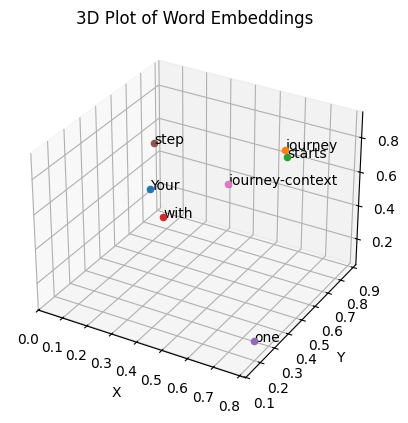

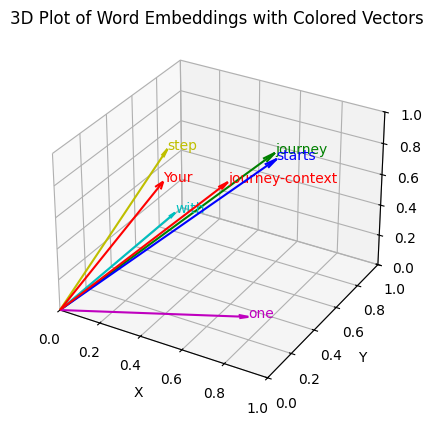

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

inputs2 = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55], # step     (x^6)
   [0.4419, 0.6515, 0.5683]] # Journey context 
)

# Corresponding words
words2 = ['Your', 'journey', 'starts', 'with', 'one', 'step', 'journey-context']

# Extract x, y, z coordinates
x_coords = inputs2[:, 0].numpy()
y_coords = inputs2[:, 1].numpy()
z_coords = inputs2[:, 2].numpy()

# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot each point and annotate with corresponding word
for x, y, z, word in zip(x_coords, y_coords, z_coords, words2):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word, fontsize=10)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Plot of Word Embeddings')
plt.show()

# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'r']

# Plot each vector with a different color and annotate with the corresponding word
for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words2, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()

<div class="alert alert-block alert-success">

Now, we can extend this computation to
calculate attention weights and context vectors for all inputs.

</div>

<div class="alert alert-block alert-success">
First, we add an additional for-loop to compute the
dot products for all pairs of inputs.

</div>

In [36]:
attn_scores = torch.empty(6, 6)

for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


<div class="alert alert-block alert-success">

We now normalize each row so that the values in
each row sum to 1:

</div>

In [37]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


<div class="alert alert-block alert-warning">

In the context of using PyTorch, the dim parameter in functions like torch.softmax specifies
the dimension of the input tensor along which the function will be computed. 

By setting
dim=-1, we are instructing the softmax function to apply the normalization along the last
dimension of the attn_scores tensor. 

If attn_scores is a 2D tensor (for example, with a
shape of [rows, columns]), dim=-1 will normalize across the columns so that the values in
each row (summing over the column dimension) sum up to 1.
    
</div>

<div class="alert alert-block alert-success">

In the third and last step, we now use these attention weights to compute all context
vectors via matrix multiplication:

</div>

In [38]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


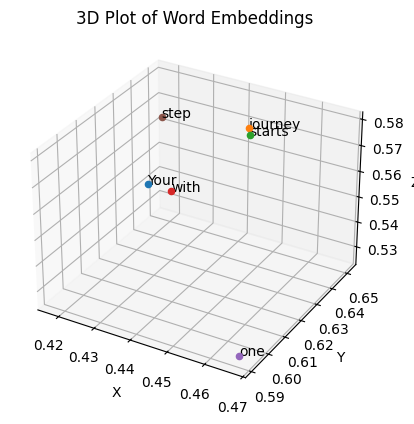

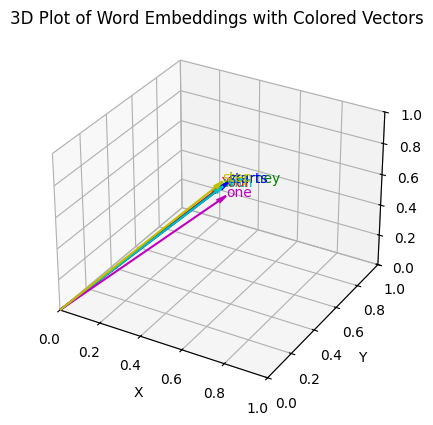

In [39]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

inputs2 = torch.tensor(
  [[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]] # Journey context 
)

# Corresponding words
words2 = ['Your', 'journey', 'starts', 'with', 'one', 'step', 'journey-context']

# Extract x, y, z coordinates
x_coords = inputs2[:, 0].numpy()
y_coords = inputs2[:, 1].numpy()
z_coords = inputs2[:, 2].numpy()

# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot each point and annotate with corresponding word
for x, y, z, word in zip(x_coords, y_coords, z_coords, words2):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word, fontsize=10)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Plot of Word Embeddings')
plt.show()

# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'r']

# Plot each vector with a different color and annotate with the corresponding word
for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words2, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()

<div class="alert alert-block alert-info">
    
Based on the result, we can see that the previously calculated context_vec_2 matches the
second row in the previous tensor exactly
</div>

<div class="alert alert-block alert-warning">

This concludes the code walkthrough of a simple self-attention mechanism.
    
</div>